# `DirectorAlign` — aligning particle orientations to the local chain tangent

`hoomd.align_angle.DirectorAlign` is an **angle force** that rotates an oriented
particle's body-frame $\hat{x}$-axis toward the direction defined by two other
particles. For an angle triplet $(i, j, k)$ it applies

$$U = \frac{k}{2}\bigl(1 - \cos(m\,\theta + \varphi_0)\bigr),\qquad
\theta = \arccos(\hat{n}_i \cdot \hat{d}),\quad
\hat{d} = \frac{\mathbf{r}_k - \mathbf{r}_j}{|\mathbf{r}_k - \mathbf{r}_j|},\quad
\hat{n}_i = \mathrm{rotate}(q_i, \hat{x}).$$

| parameter | default | meaning |
|-----------|---------|---------|
| `k` | — | alignment stiffness $[\mathrm{energy}]$ |
| `multiplicity` $m$ | 1 | `1` = polar (align $\hat n \parallel \hat d$); `2` = nematic (head–tail symmetric) |
| `phase` $\varphi_0$ | 0 | phase offset (radians); `m=1, φ₀=π` → anti-parallel |

**What this demo shows.** We build one semiflexible self-avoiding polymer where
every bead carries an orientation. Placing a `DirectorAlign` angle on each
triplet $(t, t{+}1, t{+}2)$ makes each bead's body-axis align to its **local
forward tangent** $\hat d = (\mathbf r_{t+2}-\mathbf r_{t+1})/|\cdots|$. Under
Langevin dynamics the initially-disordered orientations (all set to $+\hat x$)
lock onto the backbone tangent — an emergent, chain-wide ordering you cannot read
off the single-angle potential.

The notebook is one linear pipeline — **configure → forces → Langevin
production** — and keeps *all* plotting in the final section, so the simulation
half is self-contained and reusable on its own.

In [1]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt

import hoomd
import hoomd.md
import gsd.hoomd

from hoomd import align_angle
from polykit.generators.initial_conformations import create_constrained_random_walk

# viz/analysis helpers (numpy in, figures out) — used ONLY in the final section;
# the simulation below imports nothing from it.
import demo_viz as v

try:
    device = hoomd.device.GPU()
except Exception:
    device = hoomd.device.CPU()
print("HOOMD", hoomd.version.version, "| device:", type(device).__name__,
      "| precision", hoomd.version.floating_point_precision)

HOOMD 6.1.1 | device: GPU | precision (64, 32)


## 1. Parameters

In [2]:
# --- polymer ---
N        = 1000       # beads in the chain
PERSIST  = 0.20       # fixed turn angle (rad) of the initial worm -> smooth backbone
BOND_K   = 300.0      # harmonic bond stiffness
R0       = 1.0        # bond rest length
BEND_K   = 30.0       # harmonic bending stiffness (t0 = pi) -> persistence
ALIGN_K  = 40.0       # DirectorAlign stiffness (the plugin force under study)
DPD_A    = 100.0      # DPD conservative repulsion amplitude (soft excluded volume)

# --- thermodynamics / integration ---
kT       = 1.0
DT       = 0.005
NUM_BLOCKS, BLOCK_SIZE = 40, 1000   # Langevin production

# --- output (GSD trajectory) ---
OUT_DIR = pathlib.Path("./align_traj")
OUT_DIR.mkdir(exist_ok=True)
INIT_GSD = OUT_DIR / "init.gsd"
TRAJ_GSD = OUT_DIR / "traj.gsd"


## 2. Initial conformation and topology

We start from a **persistent (worm-like) walk** so the backbone is a smooth
curve. Each bead gets a full moment of inertia and an initial orientation
pointing along $+\hat x$ (deliberately *not* aligned to the local tangent, so we
can watch it order). The single angle type `"chain"` uses triplets
$(t, t{+}1, t{+}2)$: the harmonic bending force reads its vertex $t{+}1$
(straightening the chain) while `DirectorAlign` aligns bead $t$ to the forward
tangent $\hat d=(\mathbf r_{t+2}-\mathbf r_{t+1})$.

In [3]:
np.random.seed(0)   # reproducible initial conformation
pos = np.asarray(create_constrained_random_walk(
    N, constraint_f=lambda x: True, step_size=R0, polar_fixed=PERSIST), dtype=float)
pos -= pos.mean(axis=0)
L = 3.0 * float(np.abs(pos).max()) + 20.0   # roomy box so the swelling chain never self-images

frame = gsd.hoomd.Frame()
frame.configuration.box = [L, L, L, 0, 0, 0]
frame.particles.N = N
frame.particles.types = ["M"]
frame.particles.typeid = np.zeros(N, dtype=int)
frame.particles.position = pos
frame.particles.mass = np.ones(N)
frame.particles.moment_inertia = np.tile([1.0, 1.0, 1.0], (N, 1))
frame.particles.orientation = np.tile([1.0, 0.0, 0.0, 0.0], (N, 1))  # all +x initially

# backbone bonds (i, i+1)
frame.bonds.N = N - 1
frame.bonds.types = ["backbone"]
frame.bonds.typeid = np.zeros(N - 1, dtype=int)
frame.bonds.group = np.column_stack([np.arange(N - 1), np.arange(1, N)])

# angle triplets (t, t+1, t+2)
frame.angles.N = N - 2
frame.angles.types = ["chain"]
frame.angles.typeid = np.zeros(N - 2, dtype=int)
frame.angles.group = np.column_stack(
    [np.arange(N - 2), np.arange(1, N - 1), np.arange(2, N)])

with gsd.hoomd.open(name=str(INIT_GSD), mode="w") as f:
    f.append(frame)
print(f"{N} beads, {N-1} bonds, {N-2} angles; box L = {L:.1f}; wrote {INIT_GSD}")

1000 beads, 999 bonds, 998 angles; box L = 701.5; wrote align_traj/init.gsd


## 3. Create the simulation

In [4]:
sim = hoomd.Simulation(device=device, seed=7)
sim.create_state_from_gsd(filename=str(INIT_GSD))
# draw initial translational + angular momenta from Maxwell-Boltzmann at kT
sim.state.thermalize_particle_momenta(filter=hoomd.filter.All(), kT=kT)

## 4. Forces

Four forces act on the chain: harmonic **bonds** for connectivity, a **soft DPD**
conservative repulsion for excluded volume (bounded even at full overlap, so no
minimization is needed), a harmonic **bending** angle for persistence, and the
plugin's **`DirectorAlign`** — which shares the `"chain"` angle topology with the
bending force (HOOMD evaluates every registered angle force independently over
every angle entry).

In [5]:
# backbone connectivity
bond = hoomd.md.bond.Harmonic()
bond.params["backbone"] = dict(k=BOND_K, r0=R0)

# soft excluded volume (DPD conservative repulsion; bond & angle neighbours excluded)
# Tree neighbor list: efficient for one dilute chain in a large box (a Cell grid
# would allocate ~(L/r_cut)^3 cells and blow up memory).
nlist = hoomd.md.nlist.Tree(buffer=0.4, exclusions=["bond", "1-3"])
dpd = hoomd.md.pair.DPDConservative(nlist=nlist, default_r_cut=1.0)
dpd.params[("M", "M")] = dict(A=DPD_A)

# bending stiffness (standard harmonic angle, straight = pi)
bend = hoomd.md.angle.Harmonic()
bend.params["chain"] = dict(k=BEND_K, t0=np.pi)

# >>> the plugin force: align each bead's body-x axis to the local tangent <<<
align = align_angle.DirectorAlign()
align.params["chain"] = dict(k=ALIGN_K)   # multiplicity=1, phase=0 -> polar alignment

forces = [bond, dpd, bend, align]

## 5. Langevin production

We integrate translational **and rotational** degrees of freedom
(`integrate_rotational_dof=True`) at temperature `kT`, and stream the trajectory
to `traj.gsd`. This block is fully self-contained — it uses only HOOMD (no
`demo_viz`, no bespoke readers): it just runs and writes the trajectory, which we
analyse afterwards.

In [6]:
langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=kT)
langevin.gamma_r["M"] = (1.0, 1.0, 1.0)   # thermostat the rotational DOF too (else they stay cold)
integrator = hoomd.md.Integrator(
    dt=DT, methods=[langevin], forces=forces, integrate_rotational_dof=True)
sim.operations.integrator = integrator

gsd_writer = hoomd.write.GSD(filename=str(TRAJ_GSD), mode="wb",
                             trigger=hoomd.trigger.Periodic(BLOCK_SIZE),
                             dynamic=["property", "momentum"])
sim.operations.writers.append(gsd_writer)

thermo = hoomd.md.compute.ThermodynamicQuantities(filter=hoomd.filter.All())
sim.operations.computes.append(thermo)

sim.run(0)
for i in range(NUM_BLOCKS):
    sim.run(BLOCK_SIZE)
    if i == 0 or (i + 1) % 10 == 0:
        print(f"block {i+1:2d}/{NUM_BLOCKS}  E_P/N = {thermo.potential_energy / N:7.3f}")
gsd_writer.flush()
print(f"done: {sim.timestep} steps -> {TRAJ_GSD}")

block  1/40  E_P/N =   2.563


block 10/40  E_P/N =   2.453


block 20/40  E_P/N =   2.495


block 30/40  E_P/N =   2.483


block 40/40  E_P/N =   2.453
done: 40000 steps -> align_traj/traj.gsd


In [7]:
# --- sanity: the plugin force is actually doing the work ---
E = align.energy
Fmax = float(np.linalg.norm(align.forces, axis=1).max())
n_traj = len(gsd.hoomd.open(name=str(TRAJ_GSD)))
checks = [
    ("DirectorAlign instance", isinstance(align, align_angle.DirectorAlign)),
    ("finite non-zero energy", np.isfinite(E) and abs(E) > 0),
    ("non-zero align forces", Fmax > 0),
    ("trajectory frames written", n_traj >= NUM_BLOCKS),
]
for name, ok in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
assert all(ok for _, ok in checks)
print(f"\nalign.energy = {E:.1f},  max|F_align| = {Fmax:.1f}")

[PASS] DirectorAlign instance
[PASS] finite non-zero energy
[PASS] non-zero align forces
[PASS] trajectory frames written

align.energy = 978.2,  max|F_align| = 26.4


# ═══════ EXECUTION COMPLETE — VISUALIZATION & ANALYSIS BELOW ═══════

## 6. The system: before vs after

Left, the initial state — every bead's orientation points along $+\hat x$
(arrows), so most sit at an angle to the wandering backbone. Right, the final
state — the same segment after equilibration, with each orientation now lying
**tangent** to the backbone. Arrows are coloured by alignment quality
$|\cos\theta|$ (red → green).

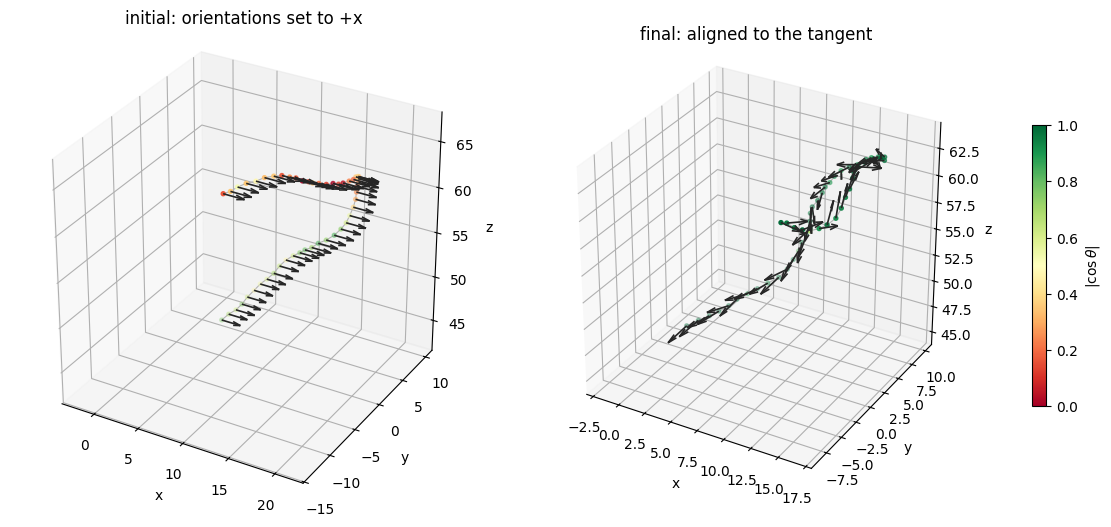

In [8]:
def state(frame):
    # unwrapped positions (undo periodic wrapping) + orientations, from a
    # get_snapshot() result or a gsd trajectory frame
    p = v.unwrap(frame.particles.position, frame.particles.image, frame.configuration.box)
    return p, np.asarray(frame.particles.orientation)


def tangent_alignment(p, q):
    # |cos theta| between each bead-t director and its forward tangent r_{t+2}-r_{t+1}
    n = v.director_from_quat(q[:-2])
    d = p[2:] - p[1:-1]
    d /= np.linalg.norm(d, axis=1, keepdims=True)
    return np.abs(np.sum(n * d, axis=1))


def padded_quality(p, q):
    c = np.full(len(p), np.nan)
    c[:-2] = tangent_alignment(p, q); c[-2:] = c[-3]
    return c


# initial state (the built worm, all orientations +x) vs final state (unwrapped)
q_init = np.tile([1.0, 0.0, 0.0, 0.0], (N, 1))
p_final, q_final = state(sim.state.get_snapshot())

a, b = N // 2 - 25, N // 2 + 25                    # a representative window
fig = plt.figure(figsize=(12, 5.2))
for k, (title, p, q) in enumerate([
        ("initial: orientations set to +x", pos, q_init),
        ("final: aligned to the tangent", p_final, q_final)]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    v.render3d(p[a:b], directors=v.director_from_quat(q)[a:b], color=padded_quality(p, q)[a:b],
               connect=True, every=1, cmap="RdYlGn", clim=(0, 1), colorbar=(k == 1),
               clabel=r"$|\cos\theta|$", arrow_len=2.2, arrow_color="0.15", title=title, ax=ax)
fig.tight_layout(); plt.show()

## 7. Alignment analysis

Reading the trajectory back, the chain-averaged alignment jumps from its
disordered start to a high plateau within the first block and stays there. At the
final frame nearly every bead's orientation lies along its local tangent, with a
small thermal spread set by `kT / ALIGN_K`.

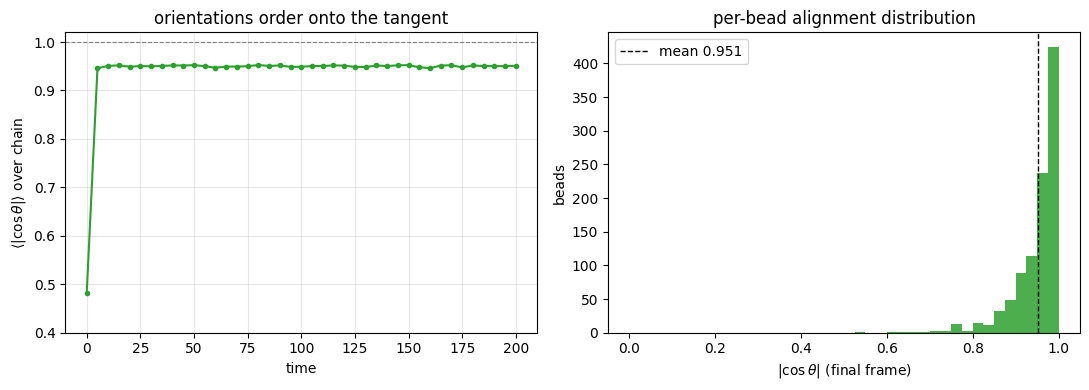

final <|cos theta|> = 0.951  (87% of beads > 0.9)


In [9]:
# time series from the trajectory (plus the t=0 point from the built state)
traj = gsd.hoomd.open(name=str(TRAJ_GSD))
times = [0.0] + [fr.configuration.step * DT for fr in traj]
series = [tangent_alignment(pos, q_init).mean()] + \
         [tangent_alignment(*state(fr)).mean() for fr in traj]

cos_bead = tangent_alignment(p_final, q_final)     # per-bead |cos theta|, final frame

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(times, series, "-o", ms=3, color="C2")
ax1.axhline(1.0, ls="--", color="0.5", lw=0.8)
ax1.set_xlabel("time"); ax1.set_ylabel(r"$\langle|\cos\theta|\rangle$ over chain")
ax1.set_ylim(0.4, 1.02); ax1.set_title("orientations order onto the tangent")
ax1.grid(alpha=0.3)

ax2.hist(cos_bead, bins=40, range=(0, 1), color="C2", alpha=0.85)
ax2.axvline(cos_bead.mean(), color="k", ls="--", lw=1, label=f"mean {cos_bead.mean():.3f}")
ax2.set_xlabel(r"$|\cos\theta|$ (final frame)"); ax2.set_ylabel("beads")
ax2.set_title("per-bead alignment distribution"); ax2.legend()
fig.tight_layout(); plt.show()

assert series[-1] > 0.8, "orientations should order onto the tangent"
print(f"final <|cos theta|> = {cos_bead.mean():.3f}  ({(cos_bead > 0.9).mean():.0%} of beads > 0.9)")

## What to try next

- **Nematic alignment:** set `align.params["chain"] = dict(k=ALIGN_K, multiplicity=2)`
  — now $\hat n$ and $-\hat n$ are equivalent, so beads align to the tangent *axis*
  (head–tail symmetric). `<|cos θ|>` still → 1 but `<cos θ>` no longer does.
- **Anti-alignment:** `dict(k=ALIGN_K, multiplicity=1, phase=np.pi)` points each
  bead *against* its tangent.
- **Stiffness sweep:** vary `ALIGN_K` vs `kT` — the equilibrium spread scales like
  `kT / ALIGN_K` (see `src/pytest/test_align_angle.py::TestEquipartition` for the
  quantitative check on a minimal 3-particle system).
- **Turn off bending** (`BEND_K = 0`): the backbone crumples, yet each orientation
  still tracks its (now rapidly varying) local tangent.